
# Performance Analysis of YOLO-based Fire Detection Pipeline

This notebook presents runtime performance analysis based on real execution metrics
collected during video processing experiments.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

In [5]:
# DB connection
conn = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="esgogiknem1",
    database="iot_video_pipeline"
)

In [6]:
# Load database tables into DataFrames
videos_df = pd.read_sql("SELECT * FROM videos", conn)
frames_df = pd.read_sql("SELECT * FROM frames", conn)
detections_df = pd.read_sql("SELECT * FROM detections", conn)
perf_df = pd.read_sql("SELECT * FROM performance_metrics", conn)

print("Videos:", len(videos_df))
print("Frames:", len(frames_df))
print("Detections:", len(detections_df))
print("Performance rows:", len(perf_df))

C:\Users\User\AppData\Local\Temp\ipykernel_24520\1656545539.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  videos_df = pd.read_sql("SELECT * FROM videos", conn)
C:\Users\User\AppData\Local\Temp\ipykernel_24520\1656545539.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  frames_df = pd.read_sql("SELECT * FROM frames", conn)
C:\Users\User\AppData\Local\Temp\ipykernel_24520\1656545539.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  detections_df = pd.read_sql("SELECT * FROM detections", conn)


Videos: 4
Frames: 3622
Detections: 25417
Performance rows: 3622


C:\Users\User\AppData\Local\Temp\ipykernel_24520\1656545539.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  perf_df = pd.read_sql("SELECT * FROM performance_metrics", conn)


In [8]:
# Preview loaded data
display(videos_df.head(2))
display(frames_df.head(2))
display(detections_df.head(2))
display(perf_df.head(2))

,video_id,video_name,camera_name,video_path,duration_sec,fps,total_frames,processed_at
0,1,cam01_car_fire.mp4,cam01,video_pipeline/input\cam01_car_fire.mp4,9.8,30.0,294,2026-04-22 21:53:22
1,2,cam02_fire_test.mp4,cam02,video_pipeline/input\cam02_fire_test.mp4,10.4,30.0,312,2026-04-22 21:53:45


,frame_id,video_id,file_name,file_path,frame_size_kb,resolution,brightness,blur_score,motion_level,camera_id,created_at
0,1,1,cam01_frame_1.jpg,video_pipeline/output/saved_frames\cam01_frame...,177.823,720x1280,137.884,272.466,0.0000,cam01,2026-04-22 21:53:22
1,2,1,cam01_frame_2.jpg,video_pipeline/output/saved_frames\cam01_frame...,182.403,720x1280,136.435,275.637,16.2448,cam01,2026-04-22 21:53:22


,detection_id,frame_id,object_type,confidence,bbox_x,bbox_y,bbox_width,bbox_height,detected_at
0,1,1,fire,0.395799,35.1101,0.0,427.118,810.372,2026-04-22 21:53:22
1,2,1,fire,0.322004,47.1077,0.0,586.508,803.831,2026-04-22 21:53:22


,metric_id,frame_id,inference_ms,processing_ms,db_insert_ms,cpu_percent,memory_mb,measured_at
0,1,1,95.9910,120.2290,6.1144,25.2,382.828,2026-04-22 21:53:22
1,2,2,27.4297,48.2836,2.1413,96.9,389.949,2026-04-22 21:53:22


In [9]:
# Overall performance summary
summary = perf_df[["inference_ms", "processing_ms", "db_insert_ms", "cpu_percent", "memory_mb"]].describe()
summary

,inference_ms,processing_ms,db_insert_ms,cpu_percent,memory_mb
count,3622.000000,3622.000000,3622.000000,3622.000000,3622.000000
mean,46.699179,81.147755,5.158262,96.822639,398.484258
std,21.805928,24.892271,2.991164,3.971440,8.444960
min,25.608900,46.901800,1.305400,25.200000,375.301000
25%,37.999225,70.358000,3.178600,94.000000,393.093000
50%,41.190250,77.495950,4.412600,98.000000,403.633000
75%,46.695800,85.343950,6.095750,100.000000,404.867000
max,345.392000,377.157000,36.433400,100.000000,406.223000


In [10]:
# Count object types
object_counts = detections_df["object_type"].value_counts()
object_counts

object_type
fire     18227
smoke     7190
Name: count, dtype: int64

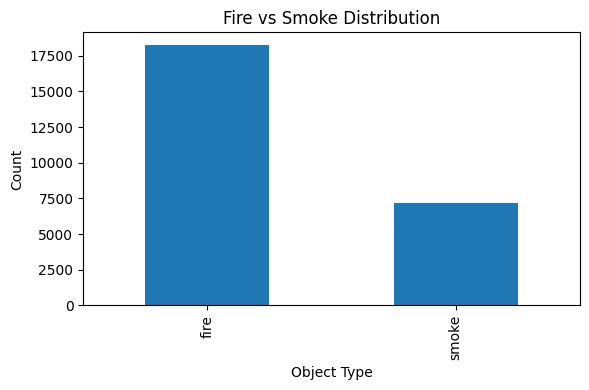

In [14]:
# Plot object distribution
plt.figure(figsize=(6, 4))
object_counts.plot(kind="bar")
plt.title("Fire vs Smoke Distribution")
plt.xlabel("Object Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/fire_vs_smoke_distribution.png")
plt.show()

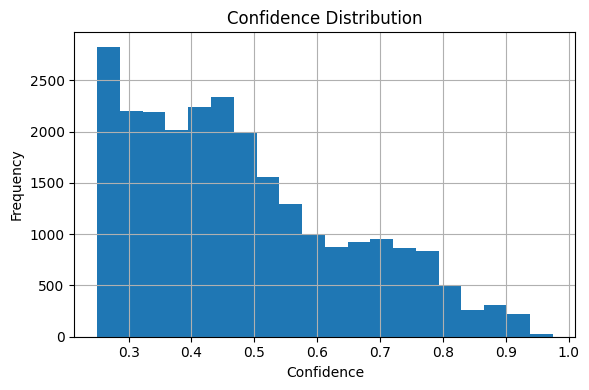

In [15]:
# Plot confidence histogram
plt.figure(figsize=(6, 4))
detections_df["confidence"].hist(bins=20)
plt.title("Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("outputs/confidence_distribution.png")
plt.show()

In [16]:
# Count saved frames per video
frames_per_video = (
    frames_df.merge(videos_df, on="video_id")
    .groupby("video_name")["frame_id"]
    .count()
    .sort_values(ascending=False)
)

frames_per_video

video_name
cam04_wildfire.mp4     2570
cam03_smoke.mp4         446
cam02_fire_test.mp4     312
cam01_car_fire.mp4      294
Name: frame_id, dtype: int64

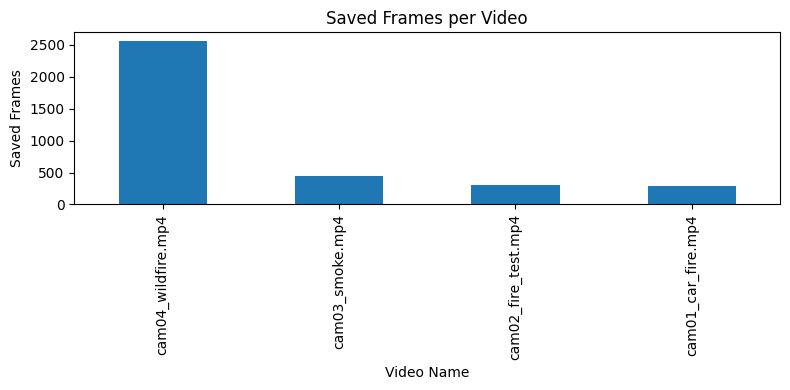

In [17]:
# Plot saved frames per video
plt.figure(figsize=(8, 4))
frames_per_video.plot(kind="bar")
plt.title("Saved Frames per Video")
plt.xlabel("Video Name")
plt.ylabel("Saved Frames")
plt.tight_layout()
plt.savefig("outputs/saved_frames_per_video.png")
plt.show()

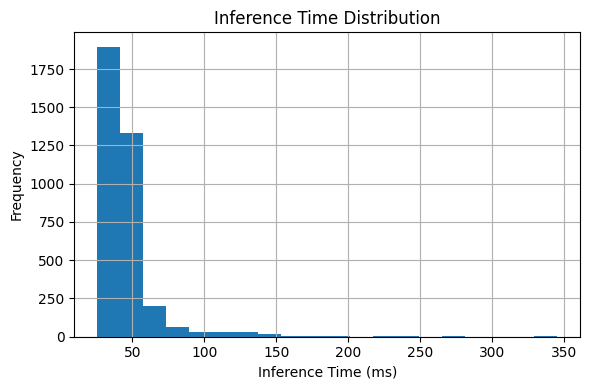

In [19]:
# Plot inference time
plt.figure(figsize=(6, 4))
perf_df["inference_ms"].hist(bins=20)
plt.title("Inference Time Distribution")
plt.xlabel("Inference Time (ms)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("outputs/inference_time_distribution.png")
plt.show()

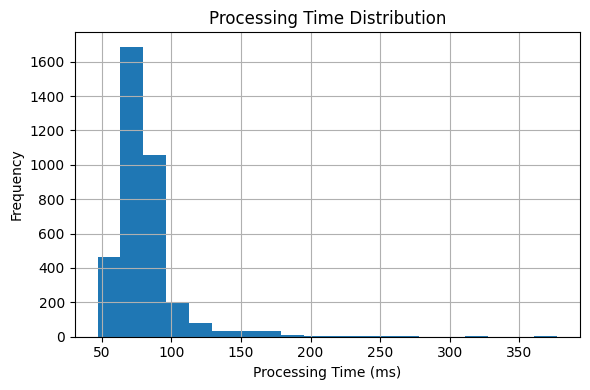

In [20]:
# Plot processing time
plt.figure(figsize=(6, 4))
perf_df["processing_ms"].hist(bins=20)
plt.title("Processing Time Distribution")
plt.xlabel("Processing Time (ms)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("outputs/processing_time_distribution.png")
plt.show()

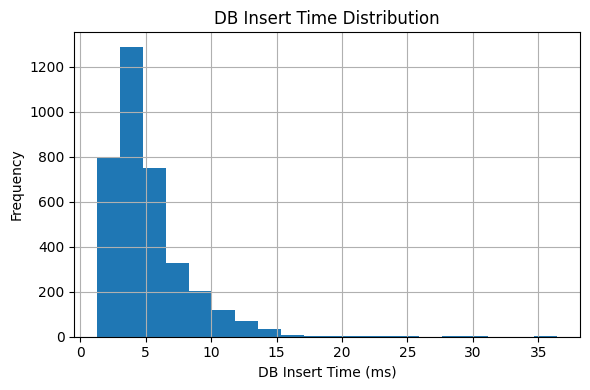

In [21]:
# Plot DB insert time
plt.figure(figsize=(6, 4))
perf_df["db_insert_ms"].hist(bins=20)
plt.title("DB Insert Time Distribution")
plt.xlabel("DB Insert Time (ms)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("outputs/db_insert_time_distribution.png")
plt.show()

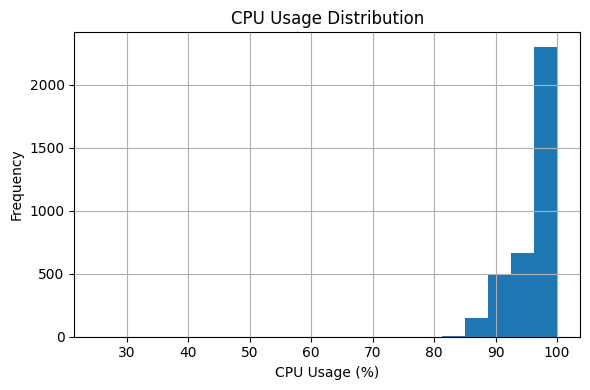

In [22]:
# Plot CPU usage
plt.figure(figsize=(6, 4))
perf_df["cpu_percent"].hist(bins=20)
plt.title("CPU Usage Distribution")
plt.xlabel("CPU Usage (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("outputs/cpu_usage_distribution.png")
plt.show()

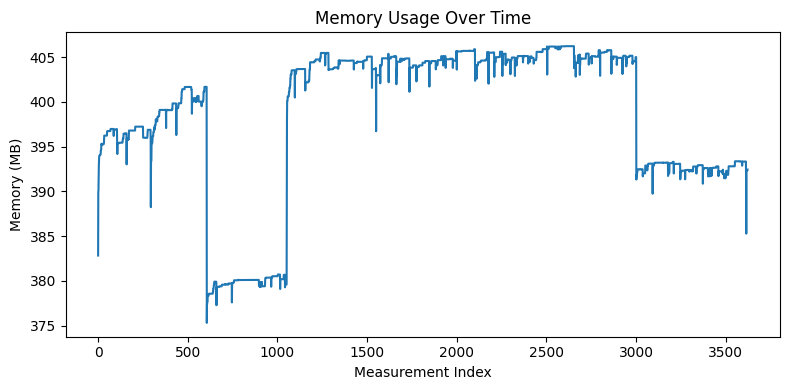

In [23]:
# Plot memory usage over rows
plt.figure(figsize=(8, 4))
plt.plot(perf_df["memory_mb"].values)
plt.title("Memory Usage Over Time")
plt.xlabel("Measurement Index")
plt.ylabel("Memory (MB)")
plt.tight_layout()
plt.savefig("outputs/memory_usage_over_time.png")
plt.show()

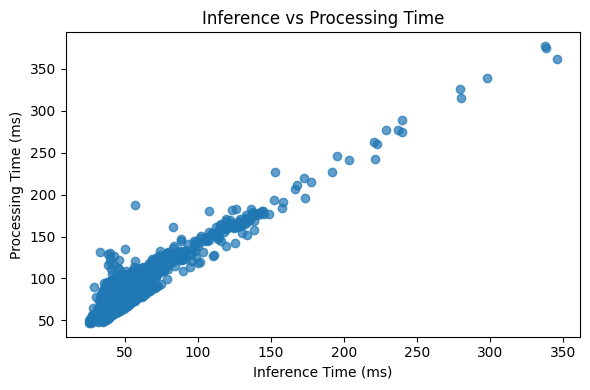

In [24]:
# Compare inference time and processing time
plt.figure(figsize=(6, 4))
plt.scatter(perf_df["inference_ms"], perf_df["processing_ms"], alpha=0.7)
plt.title("Inference vs Processing Time")
plt.xlabel("Inference Time (ms)")
plt.ylabel("Processing Time (ms)")
plt.tight_layout()
plt.savefig("outputs/inference_vs_processing.png")
plt.show()

In [25]:
# Merge performance with video information
perf_video_df = (
    perf_df.merge(frames_df[["frame_id", "video_id"]], on="frame_id")
           .merge(videos_df[["video_id", "video_name", "camera_name"]], on="video_id")
)

video_perf_summary = (
    perf_video_df.groupby(["video_name", "camera_name"])[
        ["inference_ms", "processing_ms", "db_insert_ms", "cpu_percent", "memory_mb"]
    ]
    .mean()
    .round(2)
)

video_perf_summary

,,inference_ms,processing_ms,db_insert_ms,cpu_percent,memory_mb
video_name,camera_name,,,,,
cam01_car_fire.mp4,cam01,39.99,69.02,3.85,95.97,396.22
cam02_fire_test.mp4,cam02,42.16,74.24,3.94,95.36,399.65
cam03_smoke.mp4,cam03,46.44,63.66,2.81,96.35,379.83
cam04_wildfire.mp4,cam04,48.06,86.41,5.86,97.18,401.84


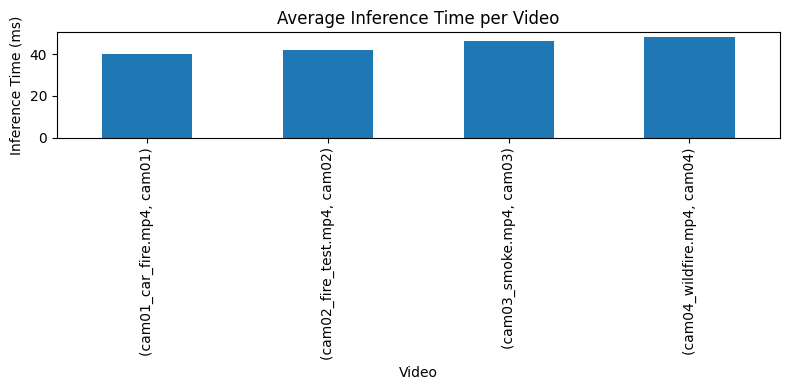

In [26]:
# Plot average inference time per video
plt.figure(figsize=(8, 4))
video_perf_summary["inference_ms"].plot(kind="bar")
plt.title("Average Inference Time per Video")
plt.xlabel("Video")
plt.ylabel("Inference Time (ms)")
plt.tight_layout()
plt.savefig("outputs/avg_inference_per_video.png")
plt.show()

In [27]:
# Count detections per frame
detections_per_frame = detections_df.groupby("frame_id").size().sort_values(ascending=False)
detections_per_frame.head(10)

frame_id
1216    30
1268    30
1269    29
1254    29
1255    29
1215    29
1258    29
1270    29
1224    28
1260    28
dtype: int64

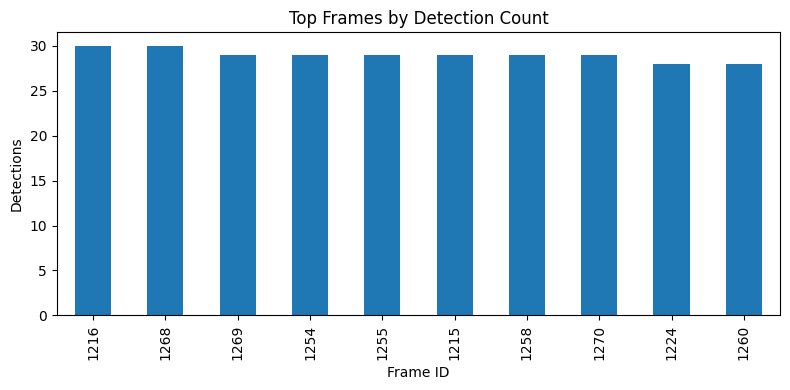

In [28]:
# Plot top detection-heavy frames
plt.figure(figsize=(8, 4))
detections_per_frame.head(10).plot(kind="bar")
plt.title("Top Frames by Detection Count")
plt.xlabel("Frame ID")
plt.ylabel("Detections")
plt.tight_layout()
plt.savefig("outputs/top_frames_by_detection_count.png")
plt.show()

In [31]:
# Convert timestamp to datetime
detections_df["detected_at"] = pd.to_datetime(detections_df["detected_at"])

# Count detections per second
detections_over_time = (
    detections_df
    .set_index("detected_at")
    .resample("1s")
    .size()
)

detections_over_time.head()

detected_at
2026-04-22 21:53:22     4
2026-04-22 21:53:23    46
2026-04-22 21:53:24    88
2026-04-22 21:53:25    76
2026-04-22 21:53:26    65
Freq: s, dtype: int64

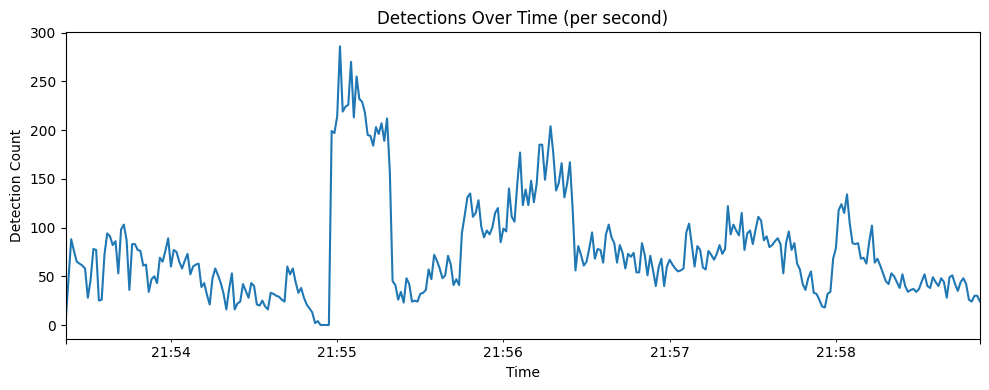

In [32]:
#Plot detections over time
plt.figure(figsize=(10, 4))
detections_over_time.plot()
plt.title("Detections Over Time (per second)")
plt.xlabel("Time")
plt.ylabel("Detection Count")
plt.tight_layout()
plt.savefig("outputs/detections_over_time.png")
plt.show()

<Figure size 600x400 with 0 Axes>

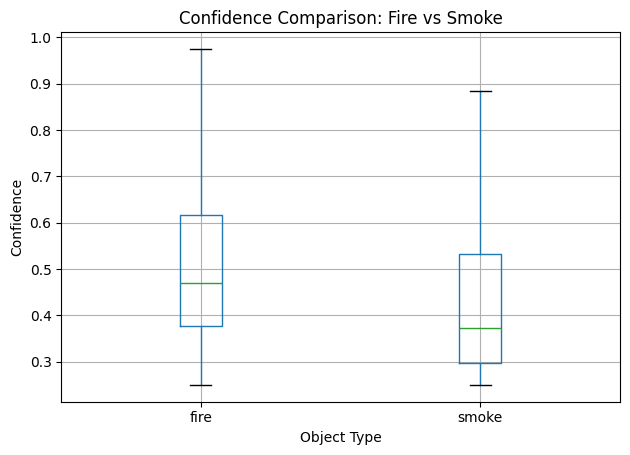

In [33]:
#Fire vs Smoke confidence comparison (boxplot)
plt.figure(figsize=(6, 4))
detections_df.boxplot(column="confidence", by="object_type")
plt.title("Confidence Comparison: Fire vs Smoke")
plt.suptitle("")
plt.xlabel("Object Type")
plt.ylabel("Confidence")
plt.tight_layout()
plt.savefig("outputs/fire_smoke_confidence_boxplot.png")
plt.show()

In [34]:
#Sliding window features preview
#Example: detections_last_5_frames
# Sort by time first
detections_df = detections_df.sort_values("detected_at")

# Rolling window: detections count over last 5 detections
detections_df["detections_last_5"] = (
    detections_df
    .groupby("object_type")["confidence"]
    .rolling(window=5)
    .count()
    .reset_index(level=0, drop=True)
)

detections_df[["object_type", "confidence", "detections_last_5"]].head(10)


,object_type,confidence,detections_last_5
0,fire,0.395799,NaN
1,fire,0.322004,NaN
2,fire,0.380168,NaN
3,fire,0.332662,NaN
29,fire,0.305934,5.0
30,fire,0.277489,5.0
31,fire,0.276329,5.0
32,fire,0.257737,5.0
33,fire,0.439492,5.0
34,fire,0.436892,5.0


<Figure size 720x480 with 0 Axes>

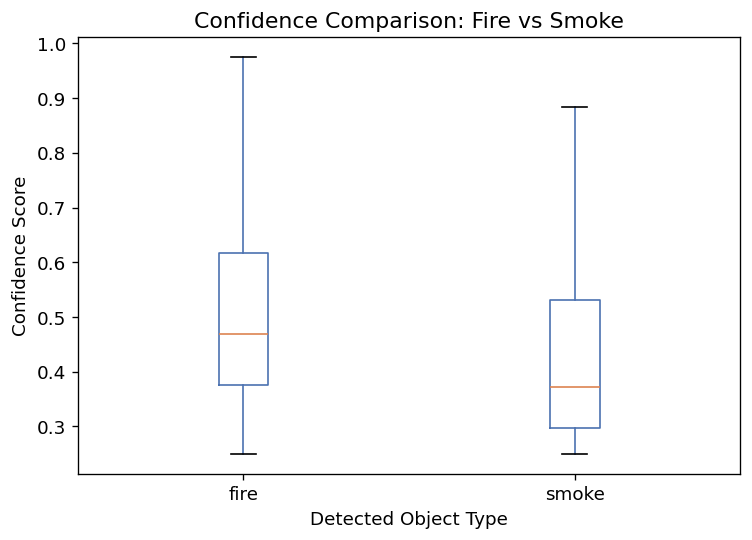

In [ ]:
plt.figure(figsize=(6, 4))

# Boxplot comparing confidence scores for fire and smoke detections
detections_df.boxplot(
    column="confidence",
    by="object_type",
    grid=False,
    color=dict(boxes="#4C72B0", whiskers="#4C72B0", medians="#DD8452")
)

# Remove the automatic Pandas title
plt.suptitle("")

# Set clean, thesis-style labels
plt.title("Confidence Comparison: Fire vs Smoke")
plt.xlabel("Detected Object Type")
plt.ylabel("Confidence Score")

plt.tight_layout()

# Save final figure for thesis usage
plt.savefig("outputs/best/fire_smoke_confidence_boxplot.png", dpi=300)
plt.show()


Նկարը X ցույց է տալիս fire և smoke հայտնաբերումների confidence score‑երի բաշխումը։ Fire դեպքերը ունեն ավելի բարձր և կայուն confidence արժեքներ, մինչդեռ smoke դեպքերը բնութագրվում են ավելի մեծ տատանմամբ։ Սա ցույց է տալիս, որ smoke հայտնաբերումները հաճախ ավելի անորոշ են և հիմնավորում է ժամանակային ագրեգացիայի ու decision-level վերլուծության կիրառման անհրաժեշտությունը։

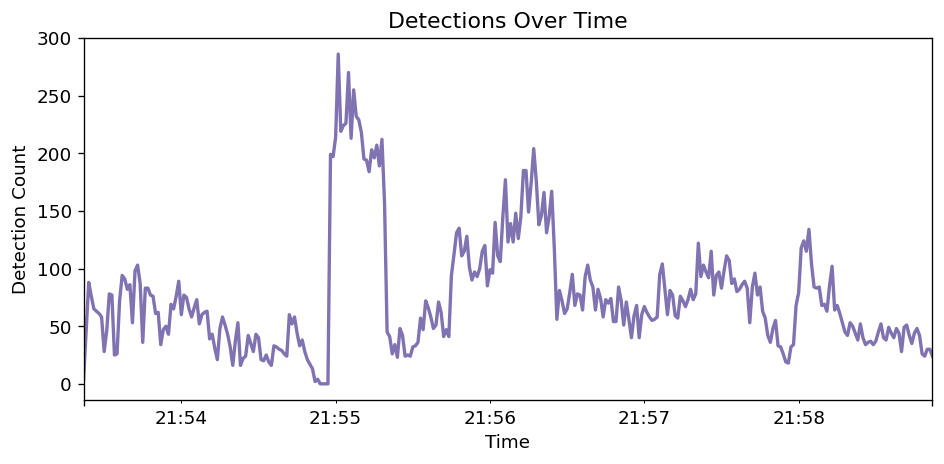

In [37]:
#Detections Over Time
import os
import matplotlib.pyplot as plt
import pandas as pd

# Ensure output directory for final thesis figures exists
os.makedirs("outputs/best", exist_ok=True)

# Convert detection timestamp to datetime format
detections_df["detected_at"] = pd.to_datetime(detections_df["detected_at"])

# Count number of detections per second (temporal aggregation)
detections_over_time = (
    detections_df
    .set_index("detected_at")
    .resample("1s")          # Aggregate detections per second
    .size()
)

# Plot detections over time
plt.figure(figsize=(8, 4))
detections_over_time.plot(
    color="#8172B2",
    linewidth=2
)

# Set clean, thesis-style plot labels
plt.title("Detections Over Time")
plt.xlabel("Time")
plt.ylabel("Detection Count")

plt.tight_layout()

# Save figure for thesis usage
plt.savefig("outputs/best/detections_over_time.png", dpi=300)
plt.show()

Նկարը Y ցույց է տալիս fire և smoke հայտնաբերումների ժամանակային բաշխումը։
Իրական հրդեհի դեպքերում հայտնաբերումները ունեն շարունակական և խիտ ժամանակային
բնույթ, մինչդեռ աղմուկը դրսևորվում է կարճատև մեկուսացված spike‑երով։
Սա ցույց է տալիս, որ ժամանակային ագրեգացիայի կիրառումը անհրաժեշտ է
ավելի հուսալի event‑մակարդակի որոշումների համար։

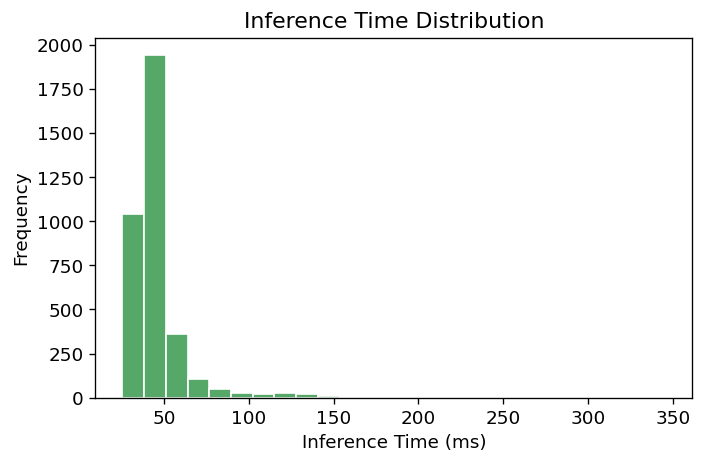

In [38]:
#Inference Time Distribution
import os
import matplotlib.pyplot as plt

# Ensure output directory for final thesis figures exists
os.makedirs("outputs/best", exist_ok=True)

# Plot inference time distribution (YOLO latency)
plt.figure(figsize=(6, 4))

plt.hist(
    perf_df["inference_ms"],
    bins=25,
    color="#55A868",
    edgecolor="white"
)

# Set clean, thesis-style labels
plt.title("Inference Time Distribution")
plt.xlabel("Inference Time (ms)")
plt.ylabel("Frequency")

plt.tight_layout()

# Save final figure for thesis usage
plt.savefig("outputs/best/inference_time_distribution.png", dpi=300)
plt.show()

Նկարը Z ներկայացնում է YOLO մոդելի inference ժամանակների բաշխումը։
Գրաֆիկից երևում է, որ inference ժամանակները կենտրոնացված են
համեմատաբար փոքր միջակայքում, ինչը վկայում է մոդելի
կայուն և կանխատեսելի աշխատանքի մասին։
Արդյունքները ցույց են տալիս, որ առաջարկվող համակարգը
կարող է իրականացնել fire/smoke detection near real‑time ռեժիմում։
Inference ժամանակների բաշխման բացակայությունը չափազանց մեծ շեղումներից
վկայում է համակարգի հուսալիության մասին իրական կիրառման պայմաններում։

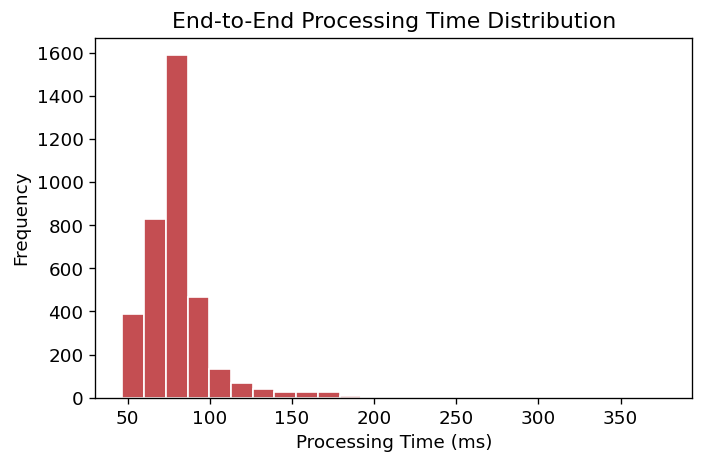

In [39]:
#nd‑to‑End Processing Time Distribution
import os
import matplotlib.pyplot as plt

# Ensure output directory for final thesis figures exists
os.makedirs("outputs/best", exist_ok=True)

# Plot end-to-end processing time distribution
plt.figure(figsize=(6, 4))

plt.hist(
    perf_df["processing_ms"],
    bins=25,
    color="#C44E52",
    edgecolor="white"
)

# Set clean, thesis-style plot labels
plt.title("End-to-End Processing Time Distribution")
plt.xlabel("Processing Time (ms)")
plt.ylabel("Frequency")

plt.tight_layout()

# Save final figure for thesis usage
plt.savefig("outputs/best/processing_time_distribution.png", dpi=300)
plt.show()

Նկարը X ներկայացնում է ամբողջ frame մշակման (end‑to‑end processing) ժամանակների բաշխումը։
Այս ժամանակը ներառում է YOLO մոդելի inference փուլը, հայտնաբերումների
վիզուալացումը, frame‑ի պահպանումը և տվյալների բազայի թարմացումը։
Գրաֆիկից երևում է, որ processing ժամանակները հիմնականում կենտրոնացված են
համեմատաբար փոքր միջակայքում, ինչը վկայում է pipeline‑ի կայուն և
կանխատեսելի աշխատանքի մասին։
Արդյունքները ցույց են տալիս, որ համակարգը կարող է իրականացնել fire/smoke
դիտարկում near real‑time ռեժիմում՝ առանց զգալի ուշացումների։

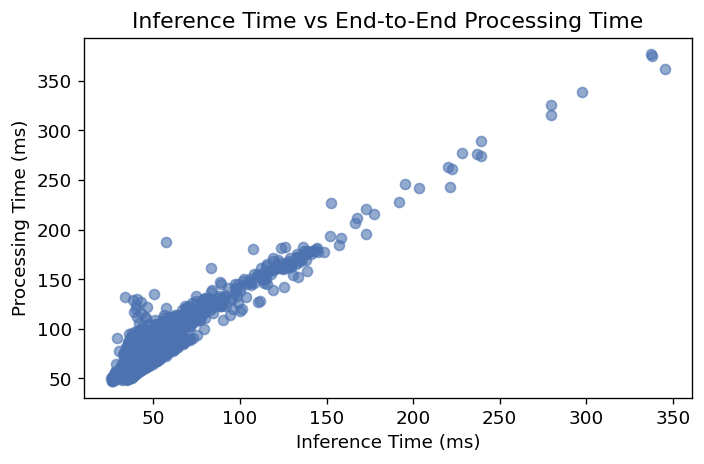

In [40]:
#Processing vs Inference Time
import os
import matplotlib.pyplot as plt

# Ensure output directory for final thesis figures exists
os.makedirs("outputs/best", exist_ok=True)

# Scatter plot: inference time vs processing time
plt.figure(figsize=(6, 4))

plt.scatter(
    perf_df["inference_ms"],
    perf_df["processing_ms"],
    alpha=0.6,
    color="#4C72B0"
)

# Set clean, thesis-style labels
plt.title("Inference Time vs End-to-End Processing Time")
plt.xlabel("Inference Time (ms)")
plt.ylabel("Processing Time (ms)")

plt.tight_layout()

# Save figure for thesis usage
plt.savefig("outputs/best/inference_vs_processing.png", dpi=300)
plt.show()

Նկարը X ներկայացնում է YOLO inference ժամանակի և ամբողջ frame մշակման
(end‑to‑end processing) ժամանակի միջև կապը։
Գրաֆիկից երևում է, որ processing ժամանակի աճը մեծապես պայմանավորված է
inference ժամանակի աճով, ինչը վկայում է, որ համակարգի հիմնական հաշվարկային
ծախսը կապված է խորքային նեյրոնային ցանցի inference փուլի հետ։
Այս արդյունքը ցույց է տալիս, որ տվյալների բազայի գործողությունները և
մնացած processing փուլերը չեն հանդիսանում bottleneck, իսկ համակարգի
արդյունավետության բարձրացման հիմնական ուղղությունը կապված է inference
փուլի օպտիմալացման հետ։

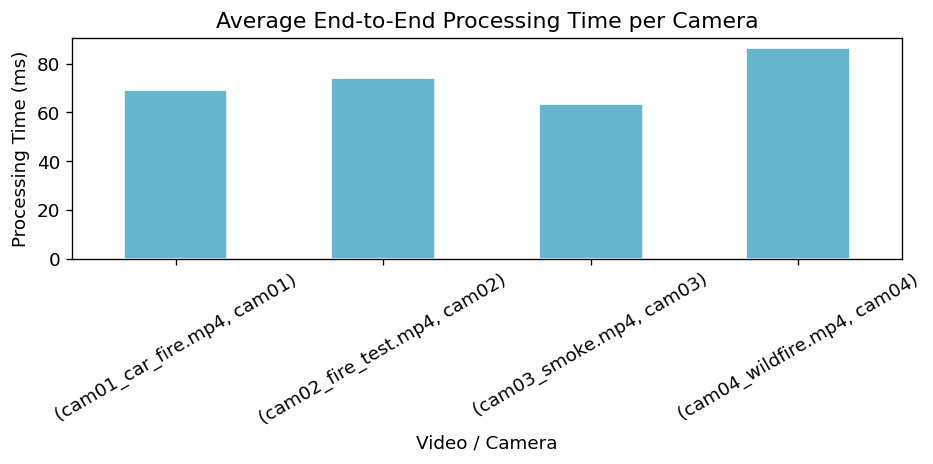

In [41]:
#Average Processing Time per Video / Camera
import os
import matplotlib.pyplot as plt

# Ensure output directory for final thesis figures exists
os.makedirs("outputs/best", exist_ok=True)

# Plot average processing time per video (camera)
plt.figure(figsize=(8, 4))

video_perf_summary["processing_ms"].plot(
    kind="bar",
    color="#64B5CD",
    edgecolor="white"
)

# Set clean, thesis-style labels
plt.title("Average End-to-End Processing Time per Camera")
plt.xlabel("Video / Camera")
plt.ylabel("Processing Time (ms)")
plt.xticks(rotation=30)

plt.tight_layout()

# Save figure for thesis usage
plt.savefig("outputs/best/avg_processing_time_per_video.png", dpi=300)
plt.show()


Նկարը Y ներկայացնում է տարբեր video‑ների (տեսախցիկների) համար
միջին end‑to‑end processing ժամանակները։
Յուրաքանչյուր video դիտարկվում է որպես առանձին camera stream, ինչը թույլ է
տալիս գնահատել համակարգի աշխատանքը տարբեր պայմաններում։
Գրաֆիկից երևում է, որ տարբեր video‑ների միջև processing ժամանակների
տատանումները սահմանափակ են, ինչը ցույց է տալիս համակարգի կայուն և
կանխատեսելի աշխատանքը բազմակի տեսախցիկների դեպքում։
Սա կարևոր է իրական կիրառման համար, որտեղ համակարգը պետք է աշխատի
միաժամանակ մի քանի աղբյուրների հետ։

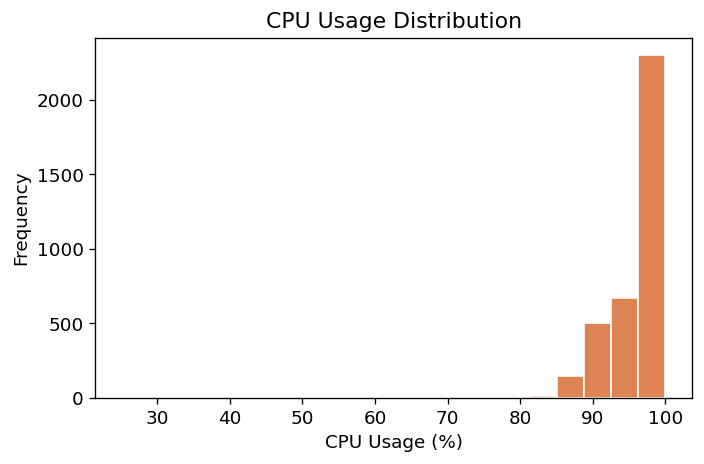

In [42]:
#CPU Usage Distribution
import os
import matplotlib.pyplot as plt

# Ensure output directory for final thesis figures exists
os.makedirs("outputs/best", exist_ok=True)

# Plot CPU usage distribution
plt.figure(figsize=(6, 4))

plt.hist(
    perf_df["cpu_percent"],
    bins=20,
    color="#DD8452",
    edgecolor="white"
)

# Set clean, thesis-style labels
plt.title("CPU Usage Distribution")
plt.xlabel("CPU Usage (%)")
plt.ylabel("Frequency")

plt.tight_layout()

# Save figure for thesis usage
plt.savefig("outputs/best/cpu_usage_distribution.png", dpi=300)
plt.show()

Նկարը Z ներկայացնում է համակարգի CPU օգտագործման բաշխումը
շարունակական video մշակման ընթացքում։
Գրաֆիկից երևում է, որ CPU օգտագործումը բարձր է, ինչը սպասելի է
խորքային նեյրոնային ցանցի inference‑ի դեպքում։
Միևնույն ժամանակ, CPU օգտագործման բաշխումը ցույց է տալիս, որ
համակարգը աշխատում է կայուն ռեժիմում՝ առանց անկառավարելի բեռնվածքի։
Սա հաստատում է, որ առաջարկվող լուծումը կարող է գործարկվել edge միջավայրում
առանց համակարգի աշխատանքի խափանման։


## Temporal / Detection History Feature Extraction

This section computes temporal features derived from detection history.
These features aggregate frame-level detections over time and form the
foundation for event-level decision making prior to applying any
machine learning decision engine.


In [44]:
import numpy as np

# Ensure proper datetime format
detections_df["detected_at"] = pd.to_datetime(detections_df["detected_at"])

# Sort detections by time
detections_df = detections_df.sort_values("detected_at")


### Detection Count in Temporal Windows

This feature counts how many detections occurred within
the last 5 and 10 seconds for each detection timestamp.


In [45]:
# Rolling detection counts in time windows
detections_df = detections_df.set_index("detected_at")

detections_df["detections_last_5s"] = (
    detections_df["confidence"]
    .rolling("5s")
    .count()
)

detections_df["detections_last_10s"] = (
    detections_df["confidence"]
    .rolling("10s")
    .count()
)

detections_df.reset_index(inplace=True)

detections_df[["detected_at", "object_type", "detections_last_5s", "detections_last_10s"]].head(10)


,detected_at,object_type,detections_last_5s,detections_last_10s
0,2026-04-22 21:53:22,fire,1.0,1.0
1,2026-04-22 21:53:22,fire,2.0,2.0
2,2026-04-22 21:53:22,fire,3.0,3.0
3,2026-04-22 21:53:22,fire,4.0,4.0
4,2026-04-22 21:53:23,fire,5.0,5.0
5,2026-04-22 21:53:23,fire,6.0,6.0
6,2026-04-22 21:53:23,fire,7.0,7.0
7,2026-04-22 21:53:23,fire,8.0,8.0
8,2026-04-22 21:53:23,fire,9.0,9.0
9,2026-04-22 21:53:23,fire,10.0,10.0


### Average Confidence over Temporal Window

This feature computes the average confidence score
over the last 5 seconds, providing confidence stability information.


In [46]:
detections_df = detections_df.set_index("detected_at")

detections_df["avg_confidence_5s"] = (
    detections_df["confidence"]
    .rolling("5s")
    .mean()
)

detections_df.reset_index(inplace=True)

detections_df[["detected_at", "object_type", "confidence", "avg_confidence_5s"]].head(10)


,detected_at,object_type,confidence,avg_confidence_5s
0,2026-04-22 21:53:22,fire,0.395799,0.395799
1,2026-04-22 21:53:22,fire,0.322004,0.358901
2,2026-04-22 21:53:22,fire,0.380168,0.365990
3,2026-04-22 21:53:22,fire,0.332662,0.357658
4,2026-04-22 21:53:23,fire,0.354792,0.357085
5,2026-04-22 21:53:23,fire,0.385177,0.361767
6,2026-04-22 21:53:23,fire,0.329271,0.357125
7,2026-04-22 21:53:23,fire,0.486388,0.373283
8,2026-04-22 21:53:23,fire,0.466242,0.383611
9,2026-04-22 21:53:23,fire,0.322042,0.377454


### Fire-to-Smoke Ratio

This feature computes the ratio of fire detections
to total detections within the last 5 seconds.
``

In [48]:
# Create binary columns for fire and smoke
detections_df["is_fire"] = (detections_df["object_type"] == "fire").astype(int)
detections_df["is_smoke"] = (detections_df["object_type"] == "smoke").astype(int)

detections_df = detections_df.set_index("detected_at")

detections_df["fire_count_5s"] = detections_df["is_fire"].rolling("5s").sum()
detections_df["total_count_5s"] = detections_df["confidence"].rolling("5s").count()

detections_df["fire_smoke_ratio_5s"] = (
    detections_df["fire_count_5s"] / detections_df["total_count_5s"]
)

detections_df.reset_index(inplace=True)

detections_df[["detected_at", "fire_count_5s", "total_count_5s", "fire_smoke_ratio_5s"]].head(10)


,detected_at,fire_count_5s,total_count_5s,fire_smoke_ratio_5s
0,2026-04-22 21:53:22,1.0,1.0,1.0
1,2026-04-22 21:53:22,2.0,2.0,1.0
2,2026-04-22 21:53:22,3.0,3.0,1.0
3,2026-04-22 21:53:22,4.0,4.0,1.0
4,2026-04-22 21:53:23,5.0,5.0,1.0
5,2026-04-22 21:53:23,6.0,6.0,1.0
6,2026-04-22 21:53:23,7.0,7.0,1.0
7,2026-04-22 21:53:23,8.0,8.0,1.0
8,2026-04-22 21:53:23,9.0,9.0,1.0
9,2026-04-22 21:53:23,10.0,10.0,1.0


### Bounding Box Area Growth Rate

This feature captures whether the detected object area
is increasing over time, which is characteristic of real fires.

In [50]:
# Compute bounding box area
detections_df["bbox_area"] = detections_df["bbox_width"] * detections_df["bbox_height"]

# Sort by time for correct diff
detections_df = detections_df.sort_values("detected_at")

# Compute area growth rate
detections_df["area_growth"] = detections_df["bbox_area"].diff()

detections_df[["detected_at", "bbox_area", "area_growth"]].head(10)

,detected_at,bbox_area,area_growth
0,2026-04-22 21:53:22,346124.467896,NaN
1,2026-04-22 21:53:22,471453.312148,125328.844252
2,2026-04-22 21:53:22,325654.725984,-145798.586164
3,2026-04-22 21:53:22,409249.915305,83595.189321
4,2026-04-22 21:53:23,393149.898890,-16100.016415
6,2026-04-22 21:53:23,315569.134166,-77580.764724
7,2026-04-22 21:53:23,408137.030704,92567.896538
8,2026-04-22 21:53:23,299680.527817,-108456.502887
9,2026-04-22 21:53:23,252361.855992,-47318.671825
10,2026-04-22 21:53:23,388006.812102,135644.956110
